# PayPal Fraud Detection

Updated on: 2025-03-27 <br>
Author: Daniel Lee ([LinkedIn](https://www.linkedin.com/in/danleedata/))

Here’s a data science project inspired by a real-world problem. Use this opportunity to sharpen your skills and build a portfolio piece that will enhance your resume.

👉 To upskill in data science: [datascienceschool.com](https://datascienceschool.com) <br>
👉 To ace interviews in data/ML: [datainterview.com](https://datainterview.com)

------

Usage Terms:
This project is intended for personal and educational purposes only. For any other use, including commercial purposes or redistribution, please contact the author for written consent.

In [27]:
#@title Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for consistent result
SEED = 123
np.random.seed(SEED)

# 🎯 Step 1 - Problem Definition

Build a data science solution that addresses the following:

1. Fraud Model: Build a model that predicts the likelihood of a transaction being fraudulent based on user and transaction features. You will be provided with a dataset containing historical user information (e.g., account creation date, country, KYC status) and transaction details (e.g., currency, amount, merchant category).

2. Operationalization: How will you utilize this model to catch fraudsters? If a fraudster is identified, what should be the resulting action: LOCK_USER, ALERT_AGENT, or BOTH?

*   **LOCK_USER** - Current transaction is blocked and user’s account is LOCKED. This prevents the user from performing any transactions with their Revolut account. Access can only be restored after contacting an agent.
*   **ALERT_AGENT** - Current transaction is not blocked. An alert is sent to a transaction monitoring agent for further review.

In [6]:
# Load data
df_users = pd.read_csv('/Users/khandarc/Downloads/paypal_fraudster_dataset/paypal_users.csv')
df_transactions = pd.read_csv('/Users/khandarc/Downloads/paypal_fraudster_dataset/paypal_transactions.csv')

In [7]:
# User Data
df_users.head()

,id,has_email,phone_country,terms_version,created_date,country,birth_year,kyc,failed_sign_in_attempts,is_fraud
0,1872820f-e3ac-4c02-bdc7-727897b60043,1,GB||JE||IM||GG,2024-05-23,2023-08-05 07:33:33.341,GB,1971,PASSED,0,0
1,545ff94d-66f8-4bea-b398-84425fb2301e,1,GB||JE||IM||GG,2023-12-31,2023-03-06 10:18:59.427,GB,1982,PASSED,0,0
2,10376f1a-a28a-4885-8daa-c8ca496026bb,1,ES,2024-09-18,2024-05-29 04:41:24.672,ES,1973,PASSED,0,0
3,fd308db7-0753-4377-879f-6ecf2af14e4f,1,FR,2024-05-23,2024-05-30 17:24:23.852,FR,1986,PASSED,0,0
4,755fe256-a34d-4853-b7ca-d9bb991a86d3,1,GB||JE||IM||GG,2024-09-18,2023-08-08 15:03:33.945,GB,1989,PASSED,0,0


In [8]:
# Transaction Data
df_transactions.head()

,currency,state,created_date,merchant_category,merchant_country,entry_method,user_id,type,source,id,amount_usd,is_crypto
0,GBP,COMPLETED,2023-12-19 12:46:20.294,cafe,GBR,cont,8f99c254-7cf2-4e35-b7e4-53804d42445d,CARD_PAYMENT,GAIA,b3332e6f-7865-4d6e-b6a5-370bc75568d8,220,False
1,EUR,COMPLETED,2023-12-19 12:38:47.232,bar,AUS,cont,ed773c34-2b83-4f70-a691-6a7aa1cb9f11,CARD_PAYMENT,GAIA,853d9ff8-a007-40ef-91a2-7d81e29a309a,2885,False
2,EUR,COMPLETED,2023-12-19 12:34:39.668,NaN,CZE,cont,eb349cc1-e986-4bf4-bb75-72280a7b8680,CARD_PAYMENT,GAIA,04de8238-7828-4e46-91f1-050a9aa7a9df,1198,False
3,GBP,COMPLETED,2023-12-19 12:45:50.555,supermarket,GBR,cont,dc78fbc4-c936-45d3-a813-e2477ac6d74b,CARD_PAYMENT,GAIA,2b790b9b-c312-4098-a4b3-4830fc8cda53,249,False
4,EUR,COMPLETED,2023-12-19 12:45:32.722,NaN,FRA,cont,32958a5c-2532-42f7-94f9-127f2a812a55,CARD_PAYMENT,GAIA,6469fc3a-e535-41e9-91b9-acb46d1cc65d,1101,False


# 🗺️ Step 2 - Exploratory Data Analysis

✍️ The Exploratory Data Analysis (EDA) section delves into the provided paypal dataset to understand its characteristics, identify patterns, and uncover insights that inform model development. Here's a guideline you can consider when approaching section:

1. Generate tables and/or charts that illustrate insights.
2. Identify potential data quality issues that require addressing.
3. Discover patterns and trends that can guide feature engineering and model selection.

## Overview

In [38]:
# YOUR CODE BELOW
df_combined_paypal = pd.merge( df_transactions,df_users, left_on='user_id', right_on='id', how='left')


In [42]:
# YOUR CODE BELOW
df_combined_paypal.rename(columns={'created_date_x': 'transaction_date'}, inplace=True)
df_combined_paypal.rename(columns={'created_date_y': 'created_date'}, inplace=True)


df_combined_paypal.head()


,currency,state,transaction_date,merchant_category,merchant_country,entry_method,user_id,type,source,id_x,...,id_y,has_email,phone_country,terms_version,created_date,country,birth_year,kyc,failed_sign_in_attempts,is_fraud
0,GBP,COMPLETED,2023-12-19 12:46:20.294,cafe,GBR,cont,8f99c254-7cf2-4e35-b7e4-53804d42445d,CARD_PAYMENT,GAIA,b3332e6f-7865-4d6e-b6a5-370bc75568d8,...,8f99c254-7cf2-4e35-b7e4-53804d42445d,1,GB||JE||IM||GG,2024-05-23,2023-09-27 11:53:55.810,GB,1962,PASSED,0,0
1,EUR,COMPLETED,2023-12-19 12:38:47.232,bar,AUS,cont,ed773c34-2b83-4f70-a691-6a7aa1cb9f11,CARD_PAYMENT,GAIA,853d9ff8-a007-40ef-91a2-7d81e29a309a,...,ed773c34-2b83-4f70-a691-6a7aa1cb9f11,1,IE,2024-09-18,2023-11-18 11:57:58.248,IE,1995,PASSED,0,0
2,EUR,COMPLETED,2023-12-19 12:34:39.668,NaN,CZE,cont,eb349cc1-e986-4bf4-bb75-72280a7b8680,CARD_PAYMENT,GAIA,04de8238-7828-4e46-91f1-050a9aa7a9df,...,eb349cc1-e986-4bf4-bb75-72280a7b8680,1,CZ,2024-05-23,2023-11-20 08:58:19.777,CZ,1985,PASSED,0,0
3,GBP,COMPLETED,2023-12-19 12:45:50.555,supermarket,GBR,cont,dc78fbc4-c936-45d3-a813-e2477ac6d74b,CARD_PAYMENT,GAIA,2b790b9b-c312-4098-a4b3-4830fc8cda53,...,dc78fbc4-c936-45d3-a813-e2477ac6d74b,1,GB||JE||IM||GG,2024-09-18,2023-07-11 20:01:29.836,GB,1974,PASSED,0,0
4,EUR,COMPLETED,2023-12-19 12:45:32.722,NaN,FRA,cont,32958a5c-2532-42f7-94f9-127f2a812a55,CARD_PAYMENT,GAIA,6469fc3a-e535-41e9-91b9-acb46d1cc65d,...,32958a5c-2532-42f7-94f9-127f2a812a55,1,FR,2024-05-23,2023-11-03 15:02:04.661,FR,1991,PASSED,0,0


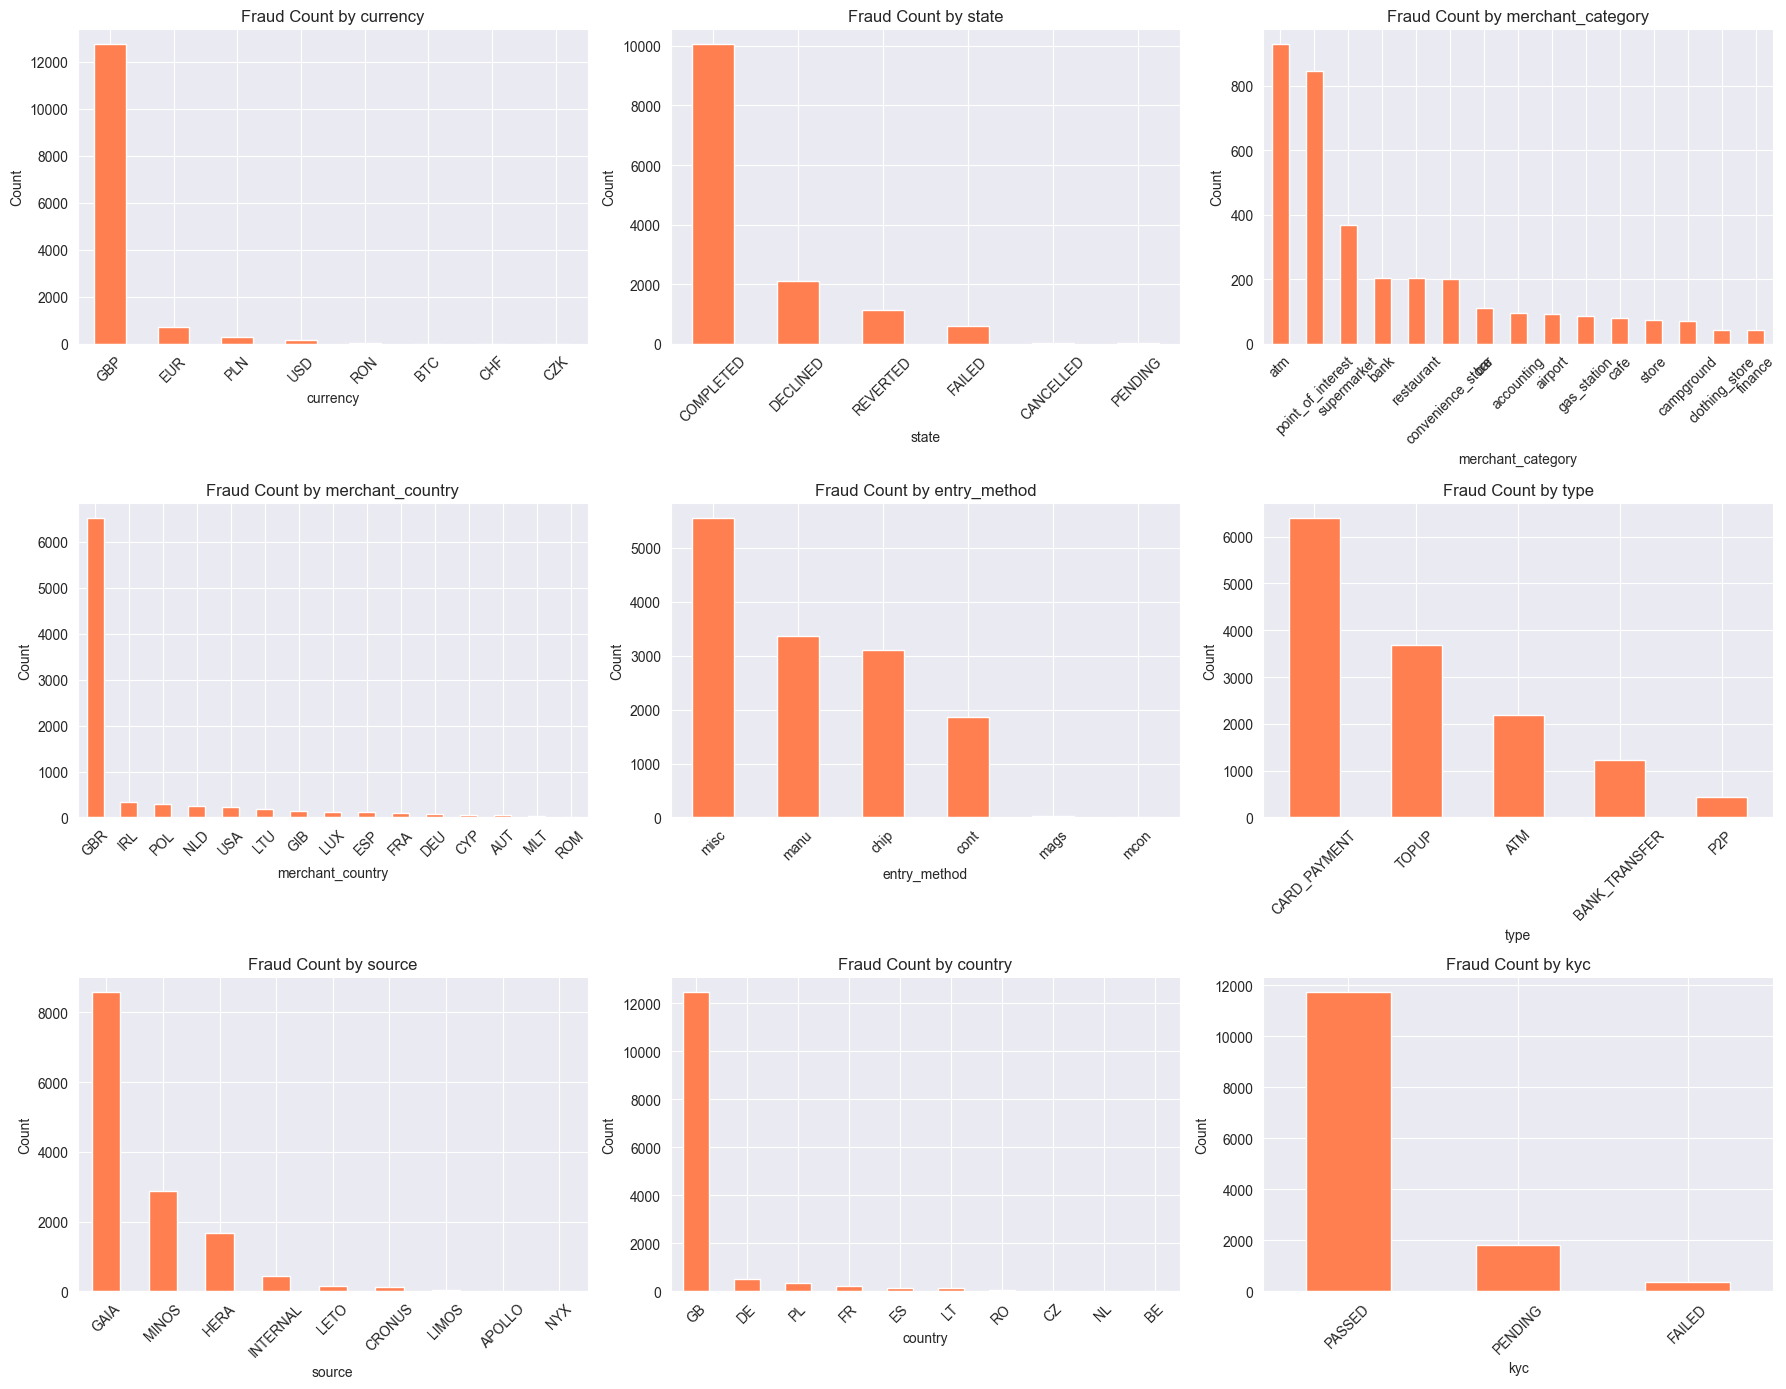

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    fraud_count = df_combined_paypal[df_combined_paypal['is_fraud'] == 1].groupby(col).size().sort_values(ascending=False).head(15)
    fraud_count.plot(kind='bar', ax=axes[i], color='coral')
    axes[i].set_title(f'Fraud Count by {col}')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



## Plotting

In [43]:
# YOUR CODE BELOW
df_combined_paypal.dtypes

currency                     str
state                        str
transaction_date             str
merchant_category            str
merchant_country             str
entry_method                 str
user_id                      str
type                         str
source                       str
id_x                         str
amount_usd                 int64
is_crypto                   bool
id_y                         str
has_email                  int64
phone_country                str
terms_version                str
created_date                 str
country                      str
birth_year                 int64
kyc                          str
failed_sign_in_attempts    int64
is_fraud                   int64
dtype: object

# 🛢️ Step 3 - Data Preparation

✍️ Data preparation transforms raw data into a suitable format for machine learning models, enhancing their accuracy and efficiency. Your task is to clean, transform, and organize the paypal data. Here are suggestions:

*   Format Fields: Ensure data types are appropriate for analysis (e.g., datetime, categorical).
*   Split Data: Divide the dataset into training and testing sets to evaluate model performance robustly.

💡 You are not restricted to these steps. If you identify additional steps to enhance the data, feel free to include them!

In [44]:
# YOUR CODE BELOW
df_combined_paypal['created_date']=pd.to_datetime(df_combined_paypal['created_date'])
df_combined_paypal['transaction_date']=pd.to_datetime(df_combined_paypal['transaction_date'])
df_combined_paypal.dtypes

currency                              str
state                                 str
transaction_date           datetime64[us]
merchant_category                     str
merchant_country                      str
entry_method                          str
user_id                               str
type                                  str
source                                str
id_x                                  str
amount_usd                          int64
is_crypto                            bool
id_y                                  str
has_email                           int64
phone_country                         str
terms_version                         str
created_date               datetime64[us]
country                               str
birth_year                          int64
kyc                                   str
failed_sign_in_attempts             int64
is_fraud                            int64
dtype: object

# 🚀 Step 4 - Feature Engineering

✍️ Feature engineering boosts model performance! It's about creating new features from existing ones to help the model better understand the data and improve predictions.

Here are suggestions to help you create new features:

1. **Dummy Encoding**: Consider applying dummy encoding on categorical variables. But beaware of sparsity!
2. **Decompose Timestamps**: Decompose timestamp into year, month, day of year, and such.
3. **Aggregations**: Consider aggregating $ amount to profile transaction history of users.

💡 If you think of any other features that could be insightful, go ahead and experiment. Feature engineering is all about finding what works best for your model!

In [47]:
# YOUR CODE BELOW
df_combined_paypal['account_age_days'] = (df_combined_paypal['transaction_date'] - df_combined_paypal['created_date']).dt.days

In [48]:
df_combined_paypal.dtypes

currency                              str
state                                 str
transaction_date           datetime64[us]
merchant_category                     str
merchant_country                      str
entry_method                          str
user_id                               str
type                                  str
source                                str
id_x                                  str
amount_usd                          int64
is_crypto                            bool
id_y                                  str
has_email                           int64
phone_country                         str
terms_version                         str
created_date               datetime64[us]
country                               str
birth_year                          int64
kyc                                   str
failed_sign_in_attempts             int64
is_fraud                            int64
account_age_days                    int64
dtype: object

In [49]:
df_combined_paypal.drop(columns=['user_id', 'id_x', 'id_y', 'transaction_date', 'created_date', 'terms_version'], inplace=True)


In [54]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['currency', 'state', 'merchant_category', 'merchant_country',
            'entry_method', 'type', 'source', 'phone_country', 'country', 'kyc']

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_combined_paypal[col] = le.fit_transform(df_combined_paypal[col].astype(str))
    le_dict[col] = le


In [51]:
df_combined_paypal.head()

,currency,state,merchant_category,merchant_country,entry_method,type,source,amount_usd,is_crypto,has_email,phone_country,country,birth_year,kyc,failed_sign_in_attempts,is_fraud,account_age_days
0,9,1,19,153,1,2,3,220,False,1,24,GB,1962,PASSED,0,0,83
1,8,1,13,96,1,2,3,2885,False,1,33,IE,1995,PASSED,0,0,31
2,8,1,115,137,1,2,3,1198,False,1,15,CZ,1985,PASSED,0,0,29
3,9,1,107,153,1,2,3,249,False,1,24,GB,1974,PASSED,0,0,160
4,8,1,115,152,1,2,3,1101,False,1,23,FR,1991,PASSED,0,0,45


In [52]:
df_combined_paypal.dtypes

currency                   int64
state                      int64
merchant_category          int64
merchant_country           int64
entry_method               int64
type                       int64
source                     int64
amount_usd                 int64
is_crypto                   bool
has_email                  int64
phone_country              int64
country                      str
birth_year                 int64
kyc                          str
failed_sign_in_attempts    int64
is_fraud                   int64
account_age_days           int64
dtype: object

# 📍 Step 5 - Feature Selection

✍️ Feature selection prevents model overfitting and improves training speed. Find the most relevant features for model prediction. You can consider a method such as the univariate Feature Importance. Be aware of multicollinearity!

In [55]:
# YOUR CODE BELOW
from sklearn.feature_selection import RFE
from xgboost import XGBClassifier

X = df_combined_paypal.drop(columns=['is_fraud'])
y = df_combined_paypal['is_fraud']

model = XGBClassifier(n_estimators=50, random_state=42, use_label_encoder=False, eval_metric='logloss')

rfe = RFE(estimator=model, n_features_to_select=10, step=1)
rfe.fit(X, y)

# See which features were selected
selected = X.columns[rfe.support_]
print("Selected features:", list(selected))

# See ranking (1 = selected, higher = eliminated earlier)
ranking = pd.Series(rfe.ranking_, index=X.columns).sort_values()
print(ranking)



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [20:47:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [20:47:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [20:47:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [20:47:10] WARN

Selected features: ['currency', 'merchant_country', 'entry_method', 'type', 'source', 'amount_usd', 'phone_country', 'country', 'kyc', 'account_age_days']
currency                   1
merchant_country           1
entry_method               1
type                       1
source                     1
amount_usd                 1
phone_country              1
country                    1
kyc                        1
account_age_days           1
state                      2
has_email                  3
birth_year                 4
merchant_category          5
failed_sign_in_attempts    6
is_crypto                  7
dtype: int64


In [56]:
corr_matrix = df_combined_paypal[['phone_country', 'country', 'currency', 'merchant_country']].corr()
print(corr_matrix)


                  phone_country   country  currency  merchant_country
phone_country          1.000000  0.801046 -0.348685          0.094346
country                0.801046  1.000000 -0.341714          0.085080
currency              -0.348685 -0.341714  1.000000         -0.147029
merchant_country       0.094346  0.085080 -0.147029          1.000000


In [57]:
print(df_combined_paypal[['phone_country', 'country', 'is_fraud']].corr()['is_fraud'])


phone_country   -0.050589
country         -0.056403
is_fraud         1.000000
Name: is_fraud, dtype: float64


In [58]:
df_combined_paypal.drop(columns=['phone_country'], inplace=True)


In [59]:
# YOUR CODE BELOW
from sklearn.feature_selection import RFE
from xgboost import XGBClassifier

X = df_combined_paypal.drop(columns=['is_fraud'])
y = df_combined_paypal['is_fraud']

model = XGBClassifier(n_estimators=50, random_state=42, use_label_encoder=False, eval_metric='logloss')

rfe = RFE(estimator=model, n_features_to_select=10, step=1)
rfe.fit(X, y)

# See which features were selected
selected = X.columns[rfe.support_]
print("Selected features:", list(selected))

# See ranking (1 = selected, higher = eliminated earlier)
ranking = pd.Series(rfe.ranking_, index=X.columns).sort_values()
print(ranking)



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [20:50:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [20:50:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [20:50:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [20:50:27] WARN

Selected features: ['currency', 'state', 'merchant_country', 'entry_method', 'type', 'source', 'amount_usd', 'country', 'kyc', 'account_age_days']
currency                   1
state                      1
merchant_country           1
entry_method               1
type                       1
source                     1
amount_usd                 1
country                    1
kyc                        1
account_age_days           1
has_email                  2
birth_year                 3
merchant_category          4
failed_sign_in_attempts    5
is_crypto                  6
dtype: int64


In [60]:
selected_features = ['currency', 'state', 'merchant_country', 'entry_method',
                     'type', 'source', 'amount_usd', 'country', 'kyc', 'account_age_days']

X = df_combined_paypal[selected_features]
y = df_combined_paypal['is_fraud']

# 🤖 Step 6 - Model Selection

✍️ Model selection is where we pick the champion algorithm that will power our predictions. It's about carefully evaluating different models and choosing the one that best suits our dataset and prediction task.

Your task is to experiment with different model architectures, train them, and assess their performance.

Here are suggestions on how to start this process:

1. Baseline Model: Start by establishing a baseline performance benchmark with a simple yet effective model like XGBoost. This sets a foundation to compare against when exploring more complex approaches.

2. Hyperparameter Tuning: Fine-tune the parameters of your chosen model using techniques like grid search or random search to unlock its full potential and achieve optimal performance.

💡 Consider using the XGBoost model, or any other models (e.g., logistic regression, random forest). Do note that the labels are imbalanced. Consider sampling strategy and choose appropriate metrics like AUC for evaluation.

In [61]:
# YOUR CODE BELOW
from sklearn.model_selection import train_test_split

X = df_combined_paypal[selected_features]
y = df_combined_paypal['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [62]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Handle imbalance with scale_pos_weight
scale = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale,
    eval_metric='logloss',
    random_state=42
)

model_xgb.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

# 📊 Step 7 - Evaluation

✍️ Model evaluation is where we put our model to the test and determine its true performance. It's about rigorously assessing how well our chosen model generalizes to unseen data and identifying any areas for improvement. Your task is to evaluate your model using a variety of metrics and techniques, focusing on:

1. **Precision & Recall:** Calculate the precision and recall of the model prediction across a range of fraud probability from the model.

2. **Fraud Loss:** What is the total $ fraud loss mitigated by the model had this been productionized?

In [63]:
# YOUR CODE BELOW
y_pred = model_xgb.predict(X_test)
y_pred_proba = model_xgb.predict_proba(X_test)[:, 1]

print("AUC-ROC:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


AUC-ROC: 0.9599997027434365

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.88      0.94    124966
           1       0.14      0.89      0.25      2783

    accuracy                           0.88    127749
   macro avg       0.57      0.89      0.59    127749
weighted avg       0.98      0.88      0.92    127749


Confusion Matrix:
[[110301  14665]
 [   306   2477]]


In [65]:
# Get fraud probabilities
y_proba = model_xgb.predict_proba(X_test)[:, 1]

# Define thresholds
LOCK_THRESHOLD = 0.85    # High confidence fraud → block + lock
ALERT_THRESHOLD = 0.50   # Medium confidence → alert agent for review

# Assign actions
def assign_action(prob):
    if prob >= LOCK_THRESHOLD:
        return 'LOCK_USER'
    elif prob >= ALERT_THRESHOLD:
        return 'ALERT_AGENT'
    else:
        return 'ALLOW'

actions = pd.Series(y_proba).apply(assign_action)

# See distribution
print(actions.value_counts())


ALLOW          110607
ALERT_AGENT     13692
LOCK_USER        3450
Name: count, dtype: int64


In [66]:
results = pd.DataFrame({'actual': y_test.values, 'proba': y_proba, 'action': actions.values})

for action in ['LOCK_USER', 'ALERT_AGENT', 'ALLOW']:
    subset = results[results['action'] == action]
    fraud_rate = subset['actual'].mean()
    print(f"{action}: {len(subset)} transactions, {fraud_rate:.1%} actually fraud")


LOCK_USER: 3450 transactions, 47.7% actually fraud
ALERT_AGENT: 13692 transactions, 6.1% actually fraud
ALLOW: 110607 transactions, 0.3% actually fraud


In [68]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Find threshold where precision >= 0.70 for LOCK
lock_idx = np.where(precision[:-1] >= 0.70)[0][0]
LOCK_THRESHOLD = thresholds[lock_idx]
print(f"New LOCK threshold: {LOCK_THRESHOLD:.2f}")

# Re-apply
def assign_action(prob):
    if prob >= LOCK_THRESHOLD:
        return 'LOCK_USER'
    elif prob >= 0.50:
        return 'ALERT_AGENT'
    else:
        return 'ALLOW'

actions = pd.Series(y_proba).apply(assign_action)
print(actions.value_counts())


New LOCK threshold: 0.94
ALLOW          110607
ALERT_AGENT     15261
LOCK_USER        1881
Name: count, dtype: int64


In [69]:
actions = pd.Series(y_proba).apply(assign_action)
results = pd.DataFrame({'actual': y_test.values, 'proba': y_proba, 'action': actions.values})

for action in ['LOCK_USER', 'ALERT_AGENT', 'ALLOW']:
    subset = results[results['action'] == action]
    fraud_rate = subset['actual'].mean()
    print(f"{action}: {len(subset)} transactions, {fraud_rate:.1%} actually fraud")


LOCK_USER: 1881 transactions, 70.0% actually fraud
ALERT_AGENT: 15261 transactions, 7.6% actually fraud
ALLOW: 110607 transactions, 0.3% actually fraud


In [70]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'scale_pos_weight': [scale * 0.5, scale * 0.75, scale, scale * 1.25],
    'min_child_weight': [1, 3, 5, 7]
}

xgb_tuned = XGBClassifier(eval_metric='logloss', random_state=42)

search = RandomizedSearchCV(
    xgb_tuned,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best AUC:", search.best_score_)
print("Best params:", search.best_params_)

# Evaluate
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

print("\nTest AUC-ROC:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best AUC: 0.9677684090450014
Best params: {'subsample': 0.9, 'scale_pos_weight': 56.13399514868385, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

Test AUC-ROC: 0.9687082029682538

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95    124966
           1       0.17      0.90      0.28      2783

    accuracy                           0.90    127749
   macro avg       0.58      0.90      0.61    127749
weighted avg       0.98      0.90      0.93    127749



In [71]:
y_proba_tuned = best_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_tuned)
lock_idx = np.where(precision[:-1] >= 0.70)[0][0]
LOCK_THRESHOLD = thresholds[lock_idx]
print(f"New LOCK threshold: {LOCK_THRESHOLD:.2f}")

def assign_action(prob):
    if prob >= LOCK_THRESHOLD:
        return 'LOCK_USER'
    elif prob >= 0.50:
        return 'ALERT_AGENT'
    else:
        return 'ALLOW'

actions = pd.Series(y_proba_tuned).apply(assign_action)
results = pd.DataFrame({'actual': y_test.values, 'proba': y_proba_tuned, 'action': actions.values})

for action in ['LOCK_USER', 'ALERT_AGENT', 'ALLOW']:
    subset = results[results['action'] == action]
    fraud_rate = subset['actual'].mean()
    print(f"{action}: {len(subset)} transactions, {fraud_rate:.1%} actually fraud")


New LOCK threshold: 0.96
LOCK_USER: 2031 transactions, 70.0% actually fraud
ALERT_AGENT: 13067 transactions, 8.3% actually fraud
ALLOW: 112651 transactions, 0.2% actually fraud


# 💼 Step 8 - Operationalization

How will you utilize this model to catch fraudsters? If a fraudster is identified, what should be the resulting action: LOCK_USER, ALERT_AGENT, or BOTH?

Write a simple function which implements your logic from above. The function should accept a user_id and yield the suggested action(s) (e.g. patrol(user_id) = [‘LOCK_USER’, ‘ALERT_AGENT’])

*   **LOCK_USER** - Current transaction is blocked and user’s account is LOCKED. This prevents the user from performing any transactions with their Revolut account. Access can only be restored after contacting an agent.
*   **ALERT_AGENT** - Current transaction is not blocked. An alert is sent to a transaction monitoring agent for further review.

In [73]:
# YOUR CODE BELOW
def patrol(user_id):
    # Get the user's latest transaction features
    user_data = df_combined_paypal[df_combined_paypal['user_id'] == user_id][selected_features].iloc[-1:]

    # Get fraud probability
    prob = best_model.predict_proba(user_data)[:, 1][0]

    # Apply thresholds
    LOCK_THRESHOLD = 0.96
    ALERT_THRESHOLD = 0.50

    actions = []
    if prob >= LOCK_THRESHOLD:
        actions.append('LOCK_USER')
        actions.append('ALERT_AGENT')  # BOTH — lock + notify agent
    elif prob >= ALERT_THRESHOLD:
        actions.append('ALERT_AGENT')

    return actions if actions else ['ALLOW']

